# video1 notebook
Starter notebook.

In [1]:
import cv2
video1_path = 'videos/pedestrianCrossingMarkRemoval_01.mp4'

In [8]:
import os
output_folder = "extracted_All_framesVideo1"
os.makedirs(output_folder, exist_ok=True)

In [9]:
cap1 = cv2.VideoCapture(video1_path)

In [10]:
cap1.isOpened()

True

In [11]:
cap1 = cv2.VideoCapture(video1_path)
fps=cap1.get(cv2.CAP_PROP_FPS)
total_frames= int(cap1.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec=total_frames/fps

print('FPS:',fps)
print('Total Frames:',total_frames)
print('Video Duration(sec:)',duration_sec)
if not cap1.isOpened():
    print("Error: Cannot open video")
    exit()

FPS: 29.998181928367977
Total Frames: 495
Video Duration(sec:) 16.501


In [12]:
frame_count = 0
saved_count = 0


while True:
    ret, frame = cap1.read()
    if not ret:
        break

    if frame_count % 5 == 0:
        resized = cv2.resize(frame, (640, 480))  
        filename = os.path.join(output_folder, f"frame_{saved_count}.jpg")
        cv2.imwrite(filename, resized)
        saved_count += 1

    frame_count += 1

cap1.release()
print("Frame extraction completed!")
print("Total frames saved:", saved_count)

Frame extraction completed!
Total frames saved: 99


## Random 30-frame degradation analysis
This section:
- randomly selects 30 extracted frames,
- plots grayscale histograms,
- estimates noise, illumination issues, and blur,
- marks likely degradations per frame.

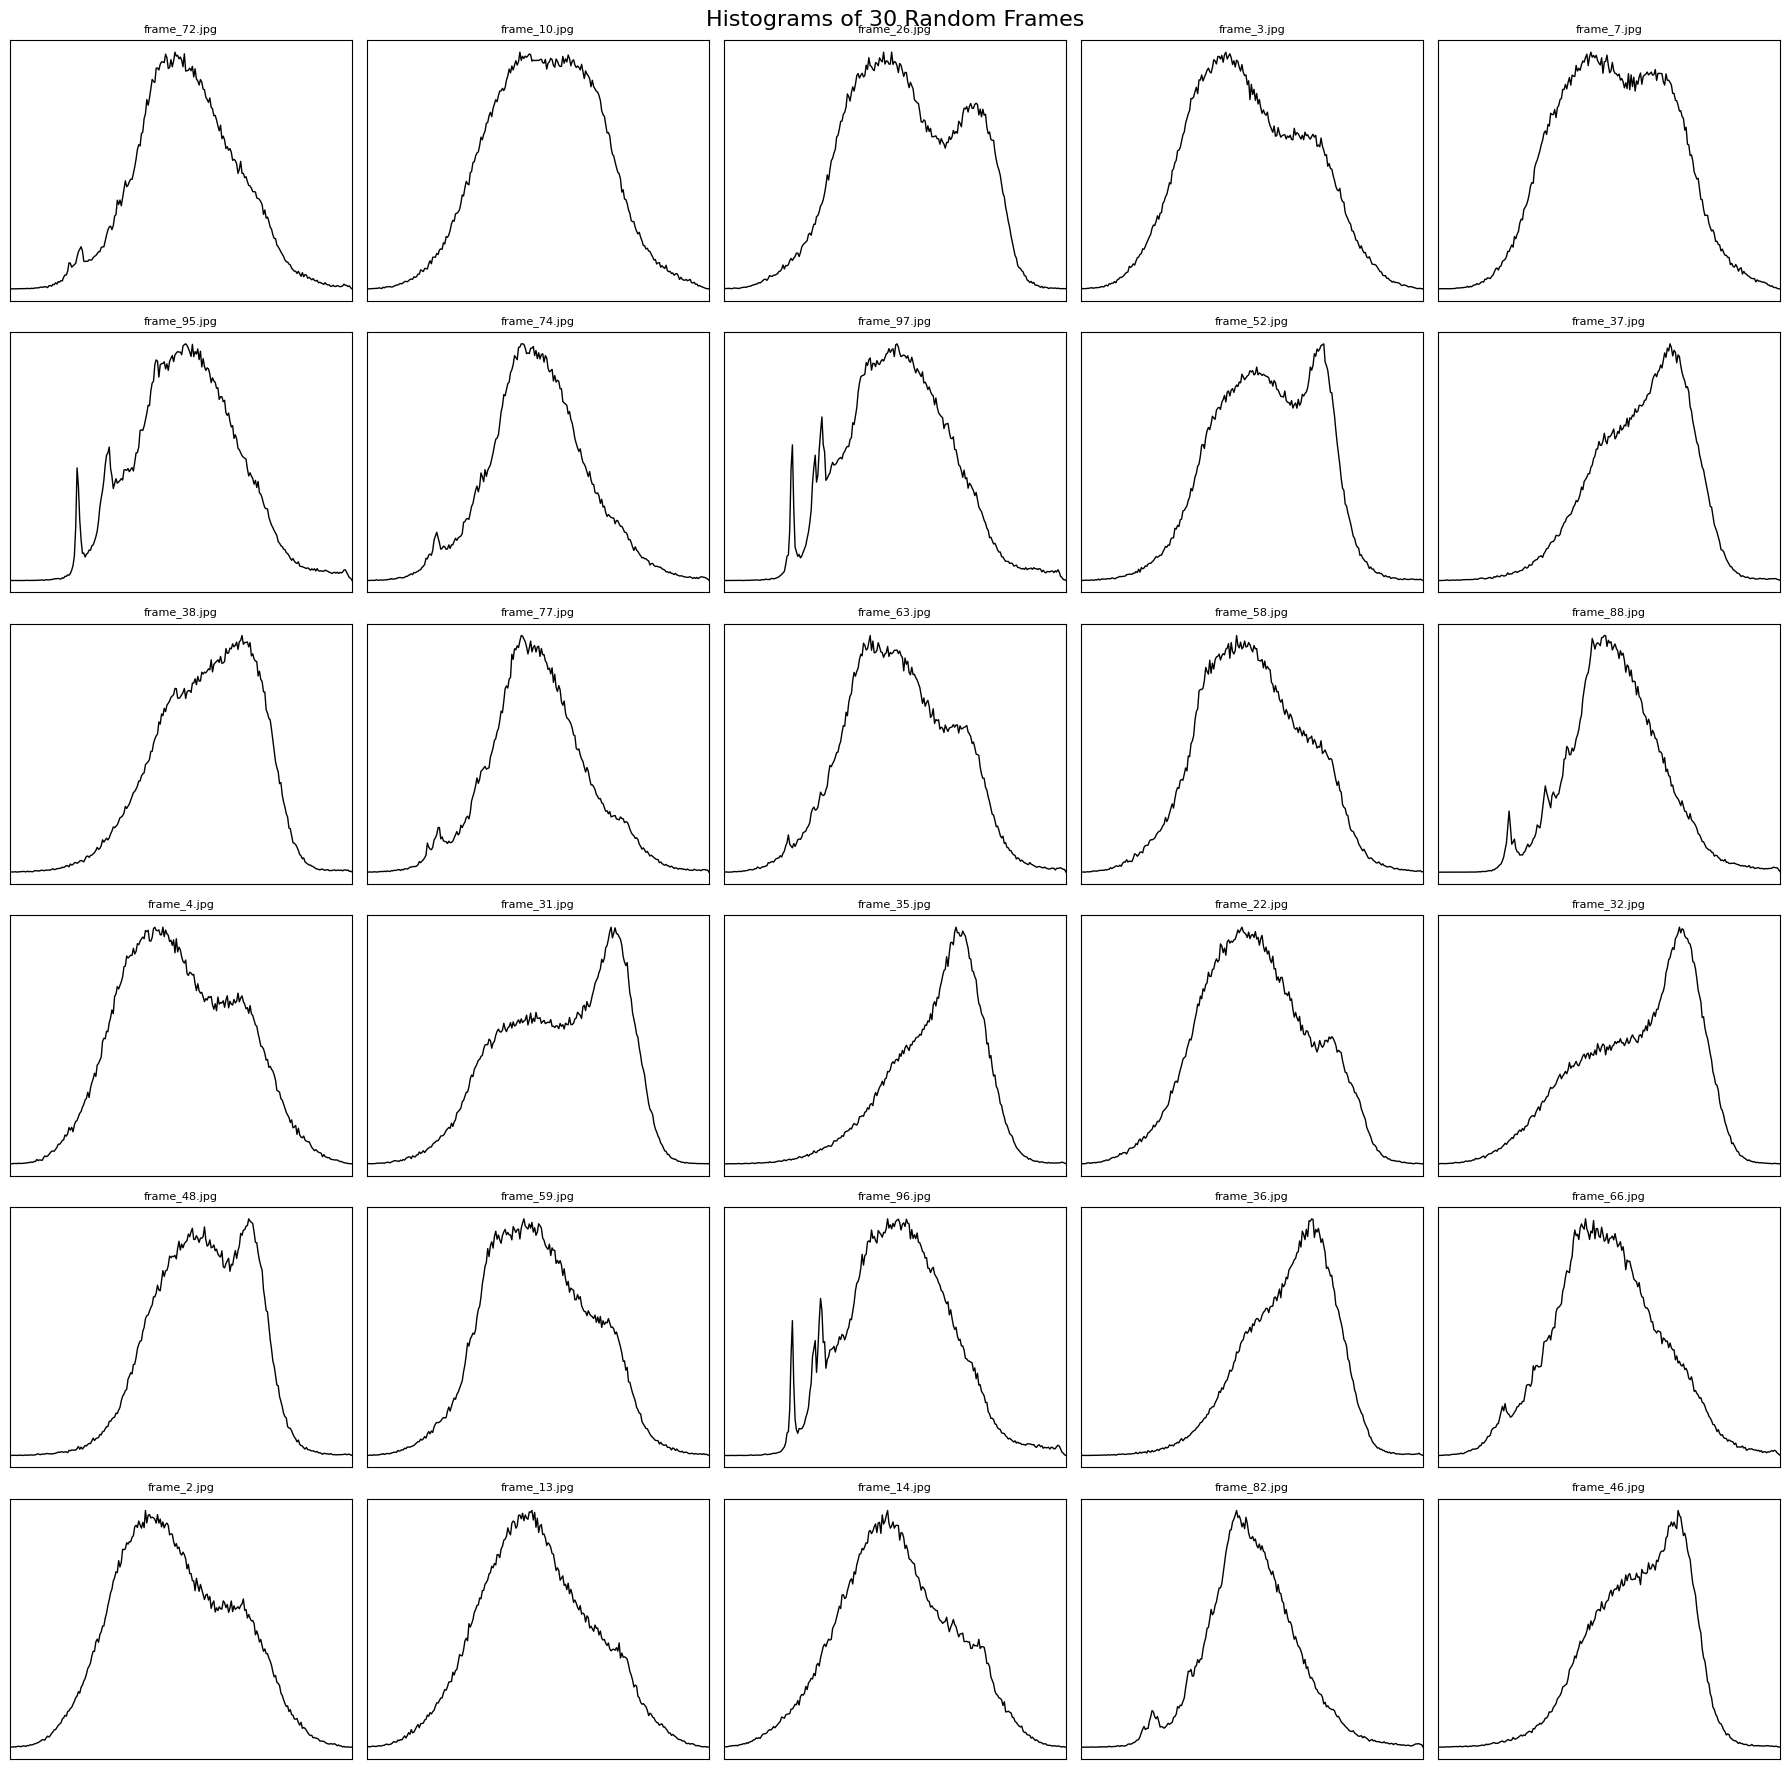

Analyzed frames: 30
Possible degradations summary:
  Noise-affected frames: 30
  Illumination-affected frames: 3
  Blur-affected frames: 0


,file,mean_brightness,sensor_noise_std,compression_blockiness,underexposed_pct,overexposed_pct,illumination_uneven_std,laplacian_var,noise_flag,illumination_flag,blur_flag
0,frame_72.jpg,131.40,21.44,0.0,0.37,1.21,21.93,9016.56,True,False,False
1,frame_10.jpg,132.74,23.15,0.0,0.68,1.72,25.77,10659.82,True,False,False
2,frame_26.jpg,136.12,22.04,0.0,0.71,1.14,31.27,9591.22,True,True,False
3,frame_3.jpg,125.41,24.22,0.0,1.05,1.37,29.12,12162.67,True,False,False
4,frame_7.jpg,132.75,22.35,0.0,0.42,1.71,27.35,10004.41,True,False,False
5,frame_95.jpg,131.03,22.26,0.0,0.10,1.67,23.61,9885.83,True,False,False
6,frame_74.jpg,127.54,22.95,0.0,0.56,1.18,19.81,10606.60,True,False,False
7,frame_97.jpg,129.13,21.83,0.0,0.09,1.70,25.14,9660.04,True,False,False
8,frame_52.jpg,138.51,22.76,0.0,0.40,0.62,20.98,10103.57,True,False,False
9,frame_37.jpg,151.99,19.27,0.0,0.21,0.95,21.38,7074.97,True,False,False


In [1]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

source_folder = "extracted_All_framesVideo1"
filtered_folder = "filteredVideo1"
os.makedirs(filtered_folder, exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
image_files = [f for f in os.listdir(source_folder) if f.lower().endswith(image_exts)]
image_files.sort()

if len(image_files) == 0:
    raise FileNotFoundError(f"No images found in '{source_folder}'")

sample_size = min(30, len(image_files))
selected_files = random.sample(image_files, sample_size)


def sensor_noise_std(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    residual = gray.astype(np.float32) - blur.astype(np.float32)
    return float(np.std(residual))


def compression_blockiness(gray):
    gray = gray.astype(np.float32)
    h, w = gray.shape

    vertical_boundaries = [x for x in range(8, w, 8)]
    horizontal_boundaries = [y for y in range(8, h, 8)]

    if len(vertical_boundaries) == 0 or len(horizontal_boundaries) == 0:
        return 0.0

    vb = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vertical_boundaries])
    hb = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in horizontal_boundaries])

    vsi = [x for x in range(9, w - 1, 8)]
    hsi = [y for y in range(9, h - 1, 8)]

    vi = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vsi]) if len(vsi) else 0.0
    hi = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in hsi]) if len(hsi) else 0.0

    return float(max(0.0, (vb + hb) - (vi + hi)))


def illumination_metrics(gray):
    under_pct = float(np.mean(gray < 40) * 100)
    over_pct = float(np.mean(gray > 215) * 100)

    illum_map = cv2.GaussianBlur(gray.astype(np.float32), (51, 51), 0)
    uneven_std = float(np.std(illum_map))

    return under_pct, over_pct, uneven_std


def blur_score(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


records = []

plt.figure(figsize=(18, 18))
for idx, fname in enumerate(selected_files, start=1):
    path = os.path.join(source_folder, fname)
    img = cv2.imread(path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    s_noise = sensor_noise_std(gray)
    c_noise = compression_blockiness(gray)
    under_pct, over_pct, uneven_std = illumination_metrics(gray)
    lap_var = blur_score(gray)
    mean_brightness = float(np.mean(gray))

    low_light_noise = (mean_brightness < 90) and (s_noise > 9.0)
    noise_flag = (s_noise > 10.0) or (c_noise > 2.5) or low_light_noise
    illumination_flag = (under_pct > 20.0) or (over_pct > 10.0) or (uneven_std > 30.0)
    blur_flag = lap_var < 80.0

    records.append(
        {
            "file": fname,
            "mean_brightness": round(mean_brightness, 2),
            "sensor_noise_std": round(s_noise, 2),
            "compression_blockiness": round(c_noise, 2),
            "underexposed_pct": round(under_pct, 2),
            "overexposed_pct": round(over_pct, 2),
            "illumination_uneven_std": round(uneven_std, 2),
            "laplacian_var": round(lap_var, 2),
            "noise_flag": bool(noise_flag),
            "illumination_flag": bool(illumination_flag),
            "blur_flag": bool(blur_flag),
        }
    )

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    plt.subplot(6, 5, idx)
    plt.plot(hist, color="black", linewidth=1)
    plt.title(fname, fontsize=8)
    plt.xlim(0, 255)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Histograms of 30 Random Frames", fontsize=16)
plt.tight_layout()
plt.show()

analysis_df = pd.DataFrame(records)

print(f"Analyzed frames: {len(analysis_df)}")
print("Possible degradations summary:")
print(f"  Noise-affected frames: {int(analysis_df['noise_flag'].sum())}")
print(f"  Illumination-affected frames: {int(analysis_df['illumination_flag'].sum())}")
print(f"  Blur-affected frames: {int(analysis_df['blur_flag'].sum())}")

analysis_df.head(10)

Filtered images saved: 30
Output folder: filteredVideo1


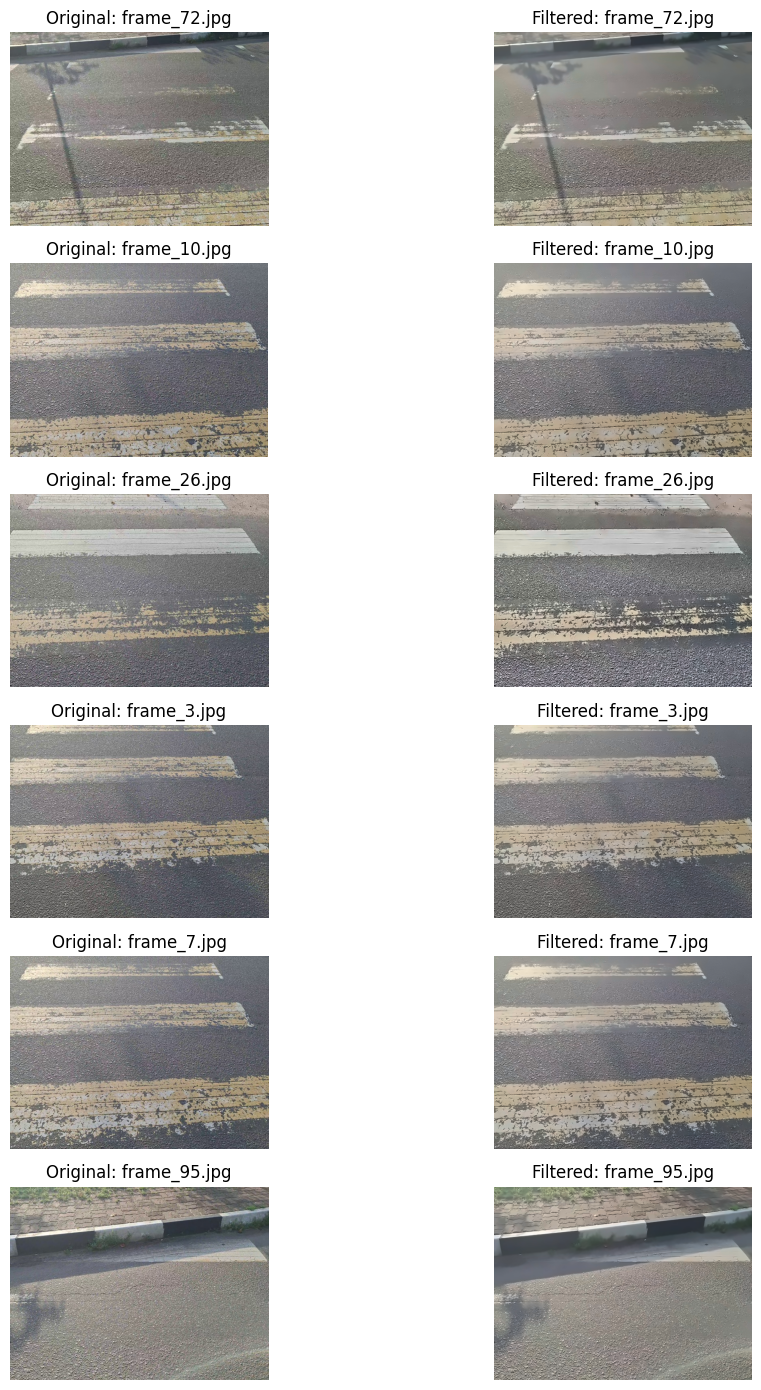

In [2]:
def apply_adaptive_filter(img_bgr, row):
    out = img_bgr.copy()

    if row["noise_flag"]:
        out = cv2.fastNlMeansDenoisingColored(out, None, 7, 7, 7, 21)

    if row["illumination_flag"]:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        out = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)

    if row["blur_flag"]:
        blur = cv2.GaussianBlur(out, (0, 0), 1.1)
        out = cv2.addWeighted(out, 1.55, blur, -0.55, 0)

    return out


saved = 0
preview_pairs = []

for _, row in analysis_df.iterrows():
    src_path = os.path.join(source_folder, row["file"])
    dst_path = os.path.join(filtered_folder, row["file"])

    img = cv2.imread(src_path)
    if img is None:
        continue

    filtered = apply_adaptive_filter(img, row)
    cv2.imwrite(dst_path, filtered)

    if len(preview_pairs) < 6:
        preview_pairs.append((img, filtered, row["file"]))

    saved += 1

print(f"Filtered images saved: {saved}")
print(f"Output folder: {filtered_folder}")

if len(preview_pairs) > 0:
    plt.figure(figsize=(12, 14))
    for i, (orig, filt, fname) in enumerate(preview_pairs, start=1):
        plt.subplot(len(preview_pairs), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview_pairs), 2, 2 * i)
        plt.imshow(cv2.cvtColor(filt, cv2.COLOR_BGR2RGB))
        plt.title(f"Filtered: {fname}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Pedestrian crossing detection and marking
This section detects likely pedestrian-crossing stripe regions in filtered images and draws box around the detected parts.

Processed images: 30
Marked-output folder: detectedCrossingVideo1
Images with at least one detected part: 30


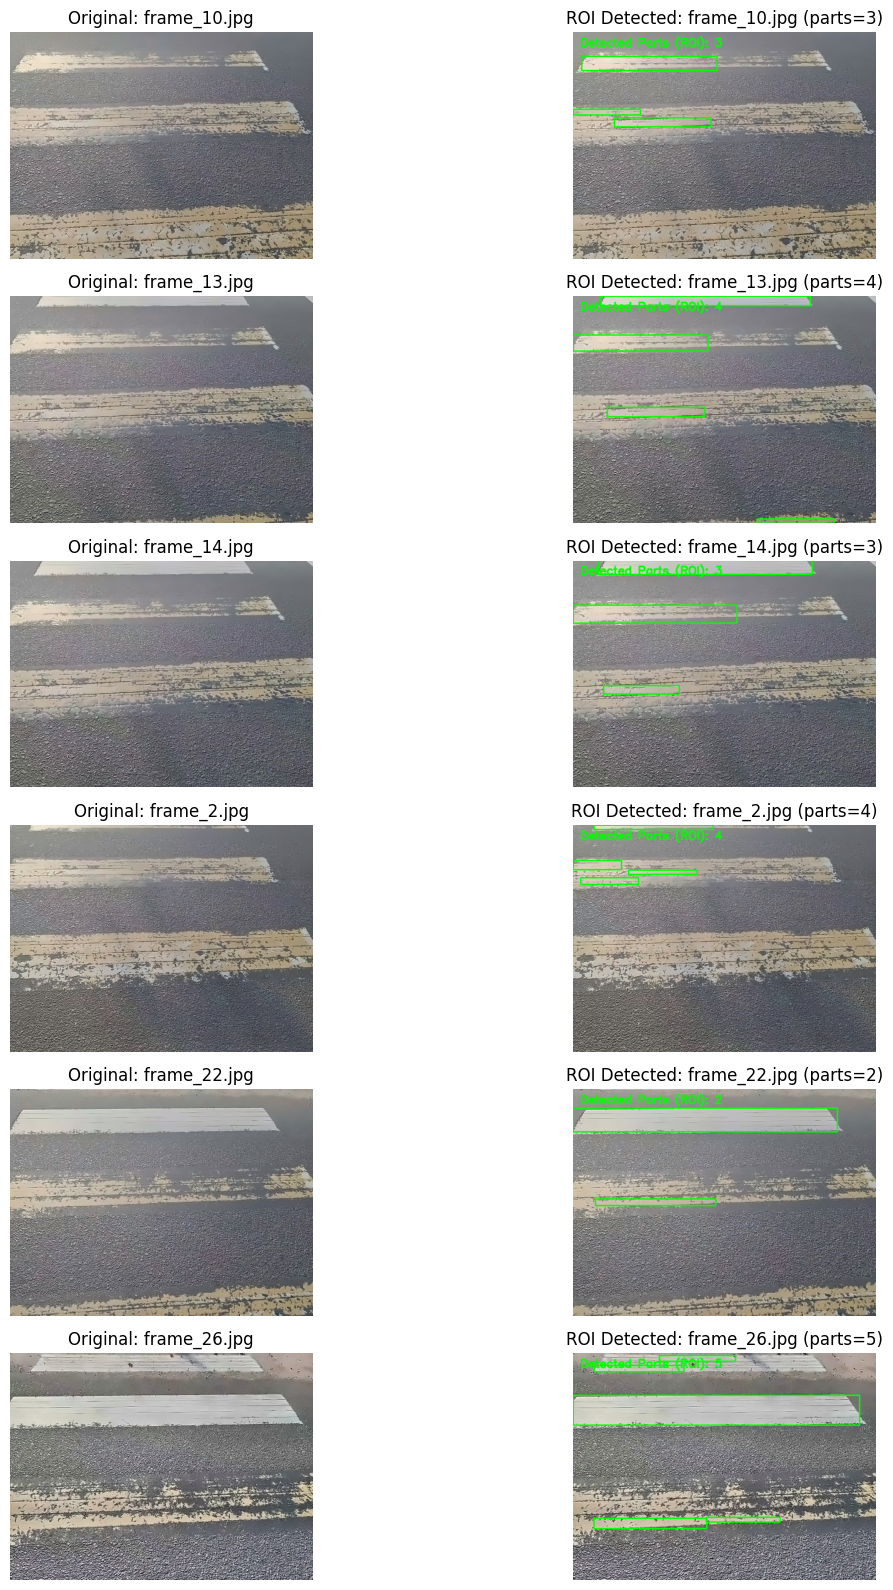

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_folder = filtered_folder
marked_folder = "detectedCrossingVideo1"
os.makedirs(marked_folder, exist_ok=True)


def detect_pedestrian_crossing_parts(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Boost contrast to make bright stripe paint easier to isolate.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray)

    # White stripe candidate mask.
    _, white_mask = cv2.threshold(gray_eq, 185, 255, cv2.THRESH_BINARY)

    # Keep horizontal stripe-like structures.
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))
    stripe_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, h_kernel, iterations=1)
    stripe_mask = cv2.morphologyEx(stripe_mask, cv2.MORPH_CLOSE, h_kernel, iterations=1)

    contours, _ = cv2.findContours(stripe_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h_img, w_img = gray.shape
    img_area = h_img * w_img

    detections = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 500 or area > 0.22 * img_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        if h == 0:
            continue

        aspect_ratio = w / float(h)
        if aspect_ratio < 2.0:
            continue

        rect = cv2.minAreaRect(cnt)
        angle = rect[2]
        if angle < -45:
            angle = 90 + angle

        # Accept near-horizontal paint stripes.
        if abs(angle) > 25:
            continue

        cx = x + w // 2
        cy = y + h // 2

        detections.append(
            {
                "bbox": (x, y, w, h),
                "center": (cx, cy),
                "area": area,
            }
        )

    detections = sorted(detections, key=lambda d: d["center"][1])
    return detections, stripe_mask


files = [f for f in os.listdir(input_folder) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
files.sort()

summary = []
preview = []

for fname in files:
    src_path = os.path.join(input_folder, fname)
    dst_path = os.path.join(marked_folder, fname)

    img = cv2.imread(src_path)
    if img is None:
        continue

    detections, _ = detect_pedestrian_crossing_parts(img)
    marked = img.copy()

    # Draw green borders around detected ROI parts (no fill)
    roi_color = (0, 255, 0)  # Green for ROI

    for d in detections:
        x, y, w, h = d["bbox"]
        cv2.rectangle(marked, (x, y), (x + w, y + h), roi_color, 2)

    label = f"Detected Parts (ROI): {len(detections)}"
    cv2.putText(marked, label, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)

    cv2.imwrite(dst_path, marked)

    summary.append({"file": fname, "detected_parts": len(detections)})

    if len(preview) < 6:
        preview.append((img, marked, fname, len(detections)))

print(f"Processed images: {len(summary)}")
print(f"Marked-output folder: {marked_folder}")
print(f"Images with at least one detected part: {sum(1 for s in summary if s['detected_parts'] > 0)}")

if len(preview) > 0:
    plt.figure(figsize=(14, 16))
    for i, (orig, marked, fname, n) in enumerate(preview, start=1):
        plt.subplot(len(preview), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview), 2, 2 * i)
        plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        plt.title(f"ROI Detected: {fname} (parts={n})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()